## 1. Imports

In [16]:
import pandas as pd
import numpy as np
import datetime
import json, os, warnings

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True,
                      "grid.alpha": 0.35, "font.size": 10})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## 2. Load Data

In [17]:
df        = pd.read_csv("C:/Users/GuruS/Downloads/NAB-master/data/realAWSCloudwatch/ec2_network_in_5abac7.csv")
cpu       = pd.read_csv("C:/Users/GuruS/Downloads/NAB-master/data/realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv")
request_c = pd.read_csv("C:/Users/GuruS/Downloads/NAB-master/data/realAWSCloudwatch/elb_request_count_8c0756.csv")

# Parse timestamps
for frame in [df, cpu, request_c]:
    frame["timestamp"] = pd.to_datetime(frame["timestamp"])

print("Shapes:", df.shape, cpu.shape, request_c.shape)
df.head()


Shapes: (4730, 2) (4032, 2) (4032, 2)


,timestamp,value
0,2014-03-01 17:36:00,42.0
1,2014-03-01 17:41:00,94.8
2,2014-03-01 17:46:00,42.0
3,2014-03-01 17:51:00,68.4
4,2014-03-01 17:56:00,68.4


## 3. Exploratory Data Analysis

In [18]:
df.describe()

,timestamp,value
count,4730,4.730000e+03
mean,2014-03-09 22:38:34.794926080,1.187146e+05
min,2014-03-01 17:36:00,4.200000e+01
25%,2014-03-05 20:07:15,4.200000e+01
50%,2014-03-09 22:38:30,6.840000e+01
75%,2014-03-14 01:09:45,1.080000e+02
max,2014-03-18 03:41:00,8.285420e+06
std,NaN,7.757187e+05


In [19]:
cpu.describe()

,timestamp,value
count,4032,4032.000000
mean,2014-02-21 14:27:30,1.829555
min,2014-02-14 14:30:00,1.604000
25%,2014-02-18 02:28:45,1.766000
50%,2014-02-21 14:27:30,1.800000
75%,2014-02-25 02:26:15,1.866000
max,2014-02-28 14:25:00,2.656000
std,NaN,0.101458


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4730 entries, 0 to 4729
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  4730 non-null   datetime64[ns]
 1   value      4730 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 74.0 KB


In [21]:
cpu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  4032 non-null   datetime64[ns]
 1   value      4032 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 63.1 KB


In [22]:
print("Missing values")
print("df       :", df.isnull().sum().to_dict())
print("cpu      :", cpu.isnull().sum().to_dict())
print("request_c:", request_c.isnull().sum().to_dict())


Missing values
df       : {'timestamp': 0, 'value': 0}
cpu      : {'timestamp': 0, 'value': 0}
request_c: {'timestamp': 0, 'value': 0}


## 4. Feature Engineering

In [23]:
def add_time_features(frame):
    frame = frame.copy()
    frame["year"]        = frame["timestamp"].dt.year
    frame["month"]       = frame["timestamp"].dt.month
    frame["day"]         = frame["timestamp"].dt.day
    frame["hour"]        = frame["timestamp"].dt.hour
    frame["minute"]      = frame["timestamp"].dt.minute
    frame["day_of_week"] = frame["timestamp"].dt.dayofweek
    return frame

df        = add_time_features(df)
cpu       = add_time_features(cpu)
request_c = add_time_features(request_c)
df.head()


,timestamp,value,year,month,day,hour,minute,day_of_week
0,2014-03-01 17:36:00,42.0,2014,3,1,17,36,5
1,2014-03-01 17:41:00,94.8,2014,3,1,17,41,5
2,2014-03-01 17:46:00,42.0,2014,3,1,17,46,5
3,2014-03-01 17:51:00,68.4,2014,3,1,17,51,5
4,2014-03-01 17:56:00,68.4,2014,3,1,17,56,5


## 5. Time-Series Visualisations

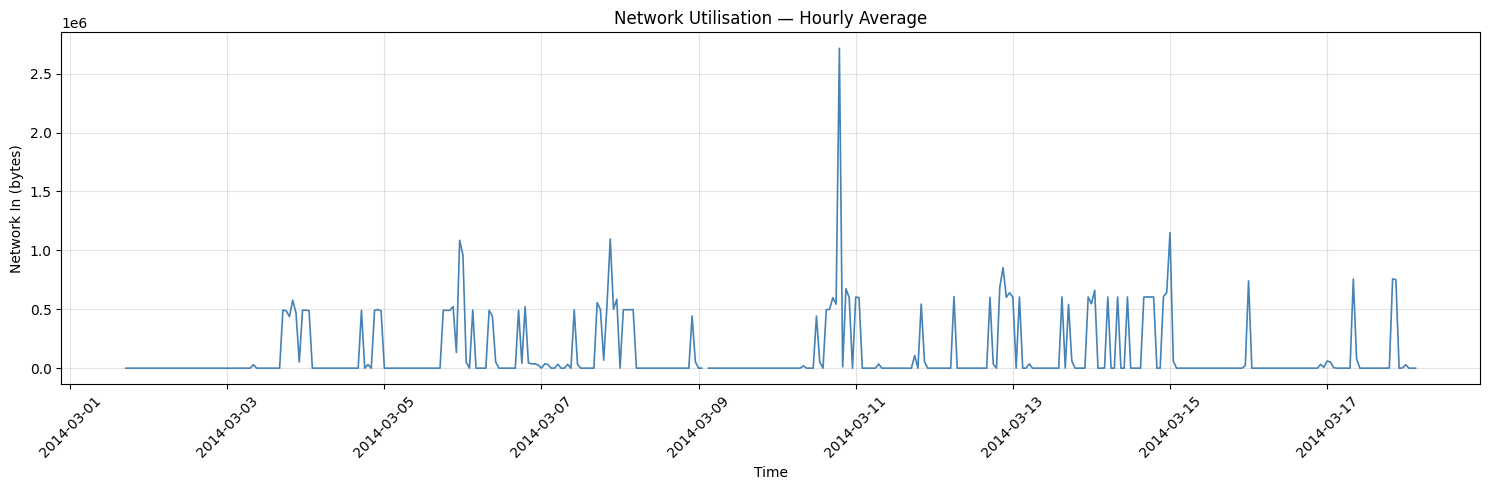

In [24]:
df_hourly = df.set_index("timestamp").resample("h").mean(numeric_only=True)

plt.figure(figsize=(15, 5))
plt.plot(df_hourly.index, df_hourly["value"], linewidth=1.2, color="steelblue")
plt.title("Network Utilisation — Hourly Average")
plt.xlabel("Time"); plt.ylabel("Network In (bytes)")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


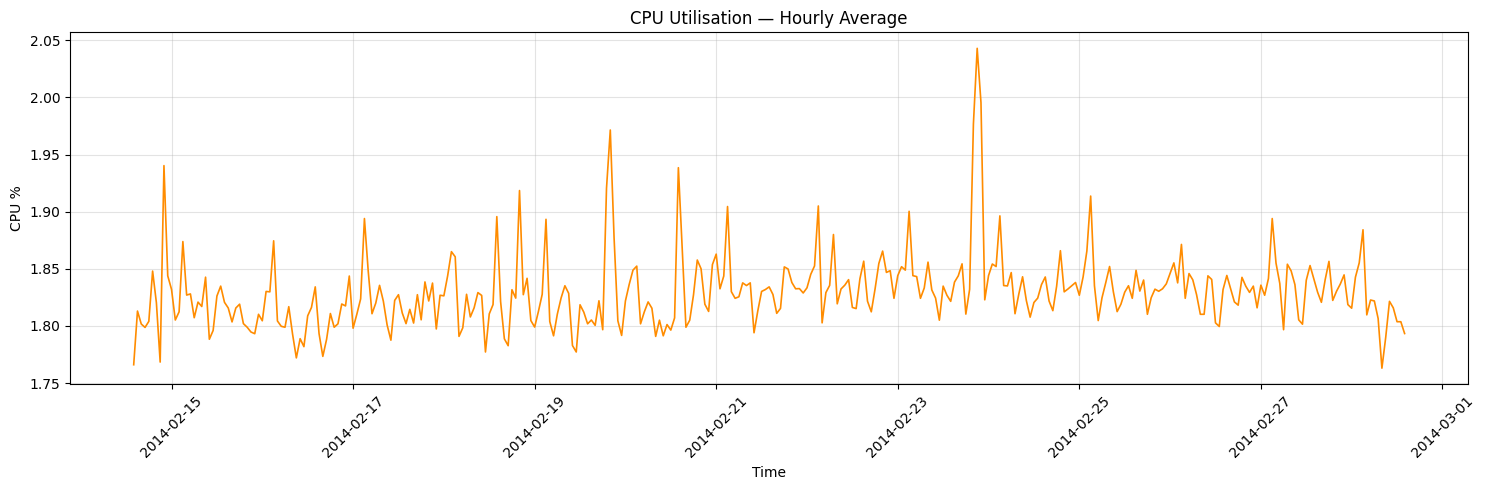

In [25]:
cpu_hourly = cpu.set_index("timestamp").resample("h").mean(numeric_only=True)

plt.figure(figsize=(15, 5))
plt.plot(cpu_hourly.index, cpu_hourly["value"], linewidth=1.2, color="darkorange")
plt.title("CPU Utilisation — Hourly Average")
plt.xlabel("Time"); plt.ylabel("CPU %")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


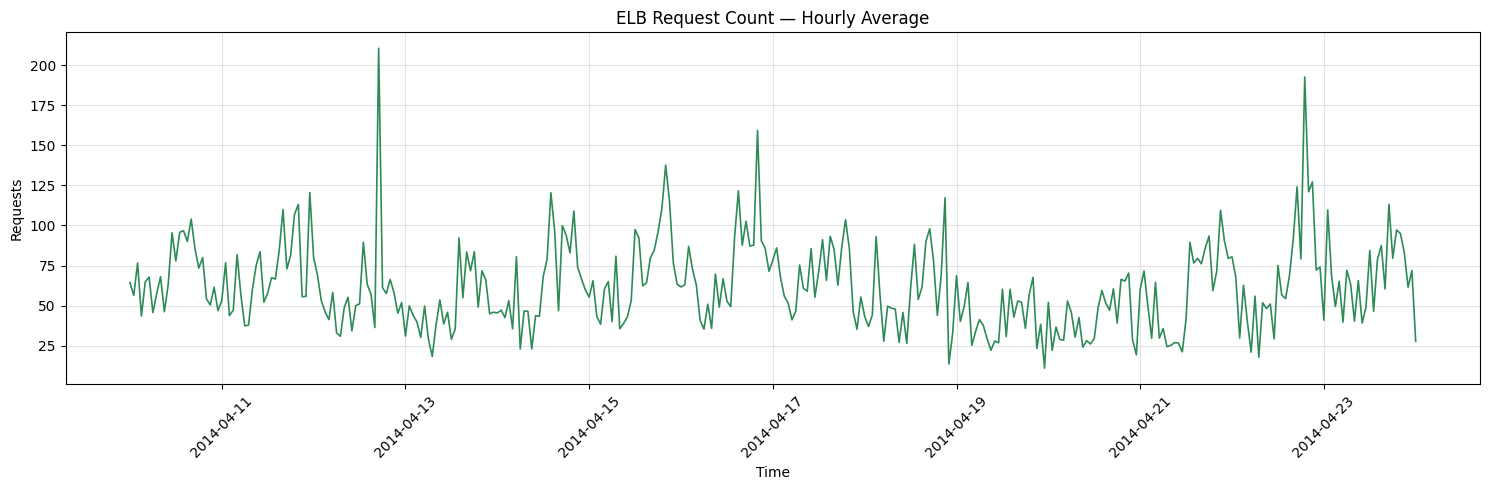

In [26]:
req_hourly = request_c.set_index("timestamp").resample("h").mean(numeric_only=True)

plt.figure(figsize=(15, 5))
plt.plot(req_hourly.index, req_hourly["value"], linewidth=1.2, color="seagreen")
plt.title("ELB Request Count — Hourly Average")
plt.xlabel("Time"); plt.ylabel("Requests")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


---
## 6. GRU Autoencoder for Anomaly Detection

### How it works
```
Raw value  →  Normalise  →  Sliding windows  →  GRU Encoder
                                                      ↓
                                               Bottleneck (hidden state)
                                                      ↓
                                              GRU Decoder  →  Reconstruct window
                                                      ↓
                                         Reconstruction Error (MSE per point)
                                                      ↓
                                    Threshold = μ + 2.5 σ  (on training data)
                                                      ↓
                                           Anomaly if error > threshold
```

The model is trained **only on the first 70 % of each series** (assumed normal).  
High reconstruction error on unseen data signals an anomaly.


### 6.1 Model Architecture

In [27]:
class GRUAutoencoder(nn.Module):
    """
    Sequence-to-sequence GRU autoencoder.
    Encoder compresses the window into a hidden state;
    Decoder reconstructs the same window from that state.
    """
    def __init__(self, seq_len: int, n_features: int = 1,
                 hidden_dim: int = 64, n_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.seq_len    = seq_len
        self.hidden_dim = hidden_dim
        self.n_layers   = n_layers

        # ── Encoder ──────────────────────────────────────────────────────
        self.encoder_gru = nn.GRU(
            input_size=n_features, hidden_size=hidden_dim,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )

        # ── Bottleneck ───────────────────────────────────────────────────
        self.bottleneck = nn.Linear(hidden_dim, hidden_dim)

        # ── Decoder ──────────────────────────────────────────────────────
        self.decoder_gru = nn.GRU(
            input_size=hidden_dim, hidden_size=hidden_dim,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.output_layer = nn.Linear(hidden_dim, n_features)

    def forward(self, x):
        # x : (batch, seq_len, n_features)
        _, h_n = self.encoder_gru(x)              # h_n : (n_layers, batch, hidden)

        # Compress the top-layer hidden state
        context = torch.relu(self.bottleneck(h_n[-1]))   # (batch, hidden)

        # Repeat context as input to decoder at every time step
        dec_input = context.unsqueeze(1).expand(-1, self.seq_len, -1)
        decoded, _ = self.decoder_gru(dec_input)
        out = self.output_layer(decoded)          # (batch, seq_len, n_features)
        return out


# Quick sanity check
_model = GRUAutoencoder(seq_len=30)
_x     = torch.randn(8, 30, 1)
print("Output shape:", _model(_x).shape)   # should be (8, 30, 1)


Output shape: torch.Size([8, 30, 1])


### 6.2 Preprocessing Helpers

In [28]:
def make_sequences(series: np.ndarray, seq_len: int) -> np.ndarray:
    """Sliding-window sequences.  shape: (N-seq_len+1, seq_len, 1)"""
    return np.array([series[i:i+seq_len] for i in range(len(series) - seq_len + 1)],
                    dtype=np.float32)[..., np.newaxis]


def prepare_data(values: np.ndarray, seq_len: int, train_frac: float = 0.70):
    """Normalise, split, build sequences, return tensors."""
    scaler = MinMaxScaler()
    norm   = scaler.fit_transform(values.reshape(-1, 1)).flatten()

    n_train = int(len(norm) * train_frac)
    train_seq = make_sequences(norm[:n_train], seq_len)
    all_seq   = make_sequences(norm,           seq_len)

    X_train = torch.tensor(train_seq, dtype=torch.float32)
    X_all   = torch.tensor(all_seq,   dtype=torch.float32)
    return X_train, X_all, scaler, n_train


### 6.3 Training Loop

In [29]:
def train_gru(model: GRUAutoencoder,
              X_train: torch.Tensor,
              epochs: int = 50,
              batch_size: int = 64,
              lr: float = 1e-3,
              patience: int = 7) -> list:
    """Train with Adam + early stopping.  Returns per-epoch loss list."""
    model.to(DEVICE)
    optimiser  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, patience=3, factor=0.5, verbose=False
    )
    criterion  = nn.MSELoss()
    loader     = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)

    best_loss, stale, best_state = np.inf, 0, None
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            optimiser.zero_grad()
            out  = model(xb)
            loss = criterion(out, xb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            epoch_loss += loss.item() * len(xb)

        epoch_loss /= len(X_train)
        history.append(epoch_loss)
        scheduler.step(epoch_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3}/{epochs}  |  loss = {epoch_loss:.6f}")

        # Early stopping
        if epoch_loss < best_loss - 1e-6:
            best_loss, stale = epoch_loss, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            stale += 1
            if stale >= patience:
                print(f"  Early stop at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    model.eval()
    return history


### 6.4 Anomaly Scoring & Thresholding

In [30]:
@torch.no_grad()
def reconstruction_errors(model: GRUAutoencoder,
                           X_all: torch.Tensor,
                           batch_size: int = 256) -> np.ndarray:
    """Per-sequence MSE reconstruction error."""
    model.eval().to(DEVICE)
    errors = []
    for i in range(0, len(X_all), batch_size):
        xb  = X_all[i:i+batch_size].to(DEVICE)
        out = model(xb)
        err = ((out - xb) ** 2).mean(dim=(1, 2))   # (batch,)
        errors.append(err.cpu().numpy())
    return np.concatenate(errors)


def get_anomaly_labels(errors: np.ndarray,
                       n_train_seq: int,
                       threshold_sigma: float = 2.5) -> tuple:
    """
    Threshold = mean + sigma * std  computed on TRAINING errors only.
    Returns (binary_labels, threshold, train_errors).
    """
    train_errors = errors[:n_train_seq]
    threshold    = train_errors.mean() + threshold_sigma * train_errors.std()
    labels       = (errors > threshold).astype(int)
    return labels, threshold, train_errors


### 6.5 Visualisation Helper

In [31]:
def plot_gru_results(df_orig, series_name, errors, labels, threshold,
                     n_train, seq_len, color="steelblue"):
    """4-panel result figure for one series."""
    # Align errors back to original index (sequences start at seq_len-1)
    offset = seq_len - 1
    ts     = df_orig["timestamp"].values
    vals   = df_orig["value"].values

    err_ts    = ts[offset:]
    label_ts  = ts[offset:]

    fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=False)
    fig.suptitle(f"GRU Autoencoder — {series_name}", fontsize=13, fontweight="bold")

    # ── Panel 1 : Raw series ───────────────────────────────────────────
    ax = axes[0]
    ax.plot(ts, vals, lw=0.8, color=color, label="value")
    ax.axvline(ts[n_train], color="gray", ls="--", lw=1.2, label="train/test split")
    ax.set_title("Original Time Series")
    ax.set_ylabel("value"); ax.legend(fontsize=8)

    # ── Panel 2 : Reconstruction error ────────────────────────────────
    ax = axes[1]
    ax.plot(err_ts, errors, lw=0.7, color="purple", label="recon error")
    ax.axhline(threshold, color="crimson", ls="--", lw=1.2, label=f"threshold={threshold:.4f}")
    ax.fill_between(err_ts, errors, threshold,
                    where=(errors > threshold), color="crimson", alpha=0.4)
    ax.axvline(ts[n_train], color="gray", ls="--", lw=1.2)
    ax.set_title("Reconstruction Error (MSE)")
    ax.set_ylabel("MSE"); ax.legend(fontsize=8)

    # ── Panel 3 : Anomaly overlay on raw series ────────────────────────
    ax = axes[2]
    ax.plot(ts, vals, lw=0.8, color=color, alpha=0.7)
    anom_mask = labels == 1
    ax.scatter(err_ts[anom_mask], vals[offset:][anom_mask],
               c="crimson", s=18, zorder=5, label=f"anomaly ({anom_mask.sum()})")
    ax.axvline(ts[n_train], color="gray", ls="--", lw=1.2, label="train/test split")
    ax.set_title("Detected Anomalies on Raw Series")
    ax.set_ylabel("value"); ax.legend(fontsize=8)

    # ── Panel 4 : Training loss (passed in separately) ─────────────────
    ax = axes[3]
    ax.text(0.5, 0.5, "Training loss plotted separately (see next cell)",
            ha="center", va="center", transform=ax.transAxes, color="gray")
    ax.set_visible(False)   # placeholder — will be replaced

    plt.tight_layout()
    plt.show()
    return fig


def plot_training_loss(history, series_name):
    plt.figure(figsize=(8, 3))
    plt.plot(history, color="teal", lw=1.5)
    plt.title(f"Training Loss — {series_name}")
    plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
    plt.tight_layout(); plt.show()


---
## 7. GRU Autoencoder — EC2 Network In


Train sequences: 3282  |  All sequences: 4701
Parameters: 91,969

  Epoch   1/60  |  loss = 0.009422
  Epoch  10/60  |  loss = 0.007860
  Epoch  20/60  |  loss = 0.007844
  Early stop at epoch 25


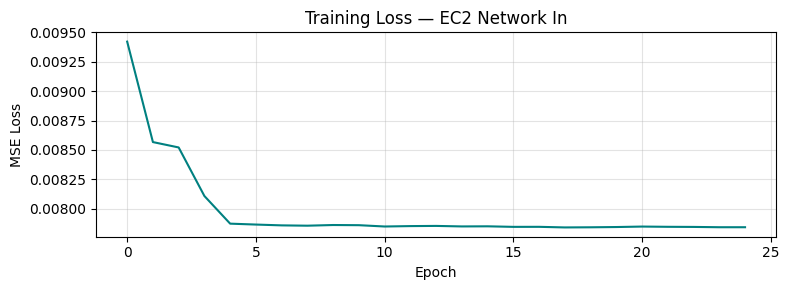

In [32]:
SEQ_LEN   = 30      # 30 × 5-min intervals = 2.5 hours context
EPOCHS    = 60
BATCH     = 64
LR        = 1e-3
SIGMA     = 2.5     # threshold multiplier (increase to be less sensitive)

# ── Prepare ────────────────────────────────────────────────────────────────
X_train_net, X_all_net, scaler_net, n_train_net = prepare_data(
    df["value"].values, SEQ_LEN
)
print(f"Train sequences: {len(X_train_net)}  |  All sequences: {len(X_all_net)}")

# ── Build & Train ──────────────────────────────────────────────────────────
net_model = GRUAutoencoder(seq_len=SEQ_LEN, n_features=1,
                           hidden_dim=64, n_layers=2, dropout=0.2)
print(f"Parameters: {sum(p.numel() for p in net_model.parameters()):,}")
print()

net_history = train_gru(net_model, X_train_net, epochs=EPOCHS,
                        batch_size=BATCH, lr=LR)
plot_training_loss(net_history, "EC2 Network In")


Threshold : 0.043382
Anomalies : 123  (2.6 % of series)


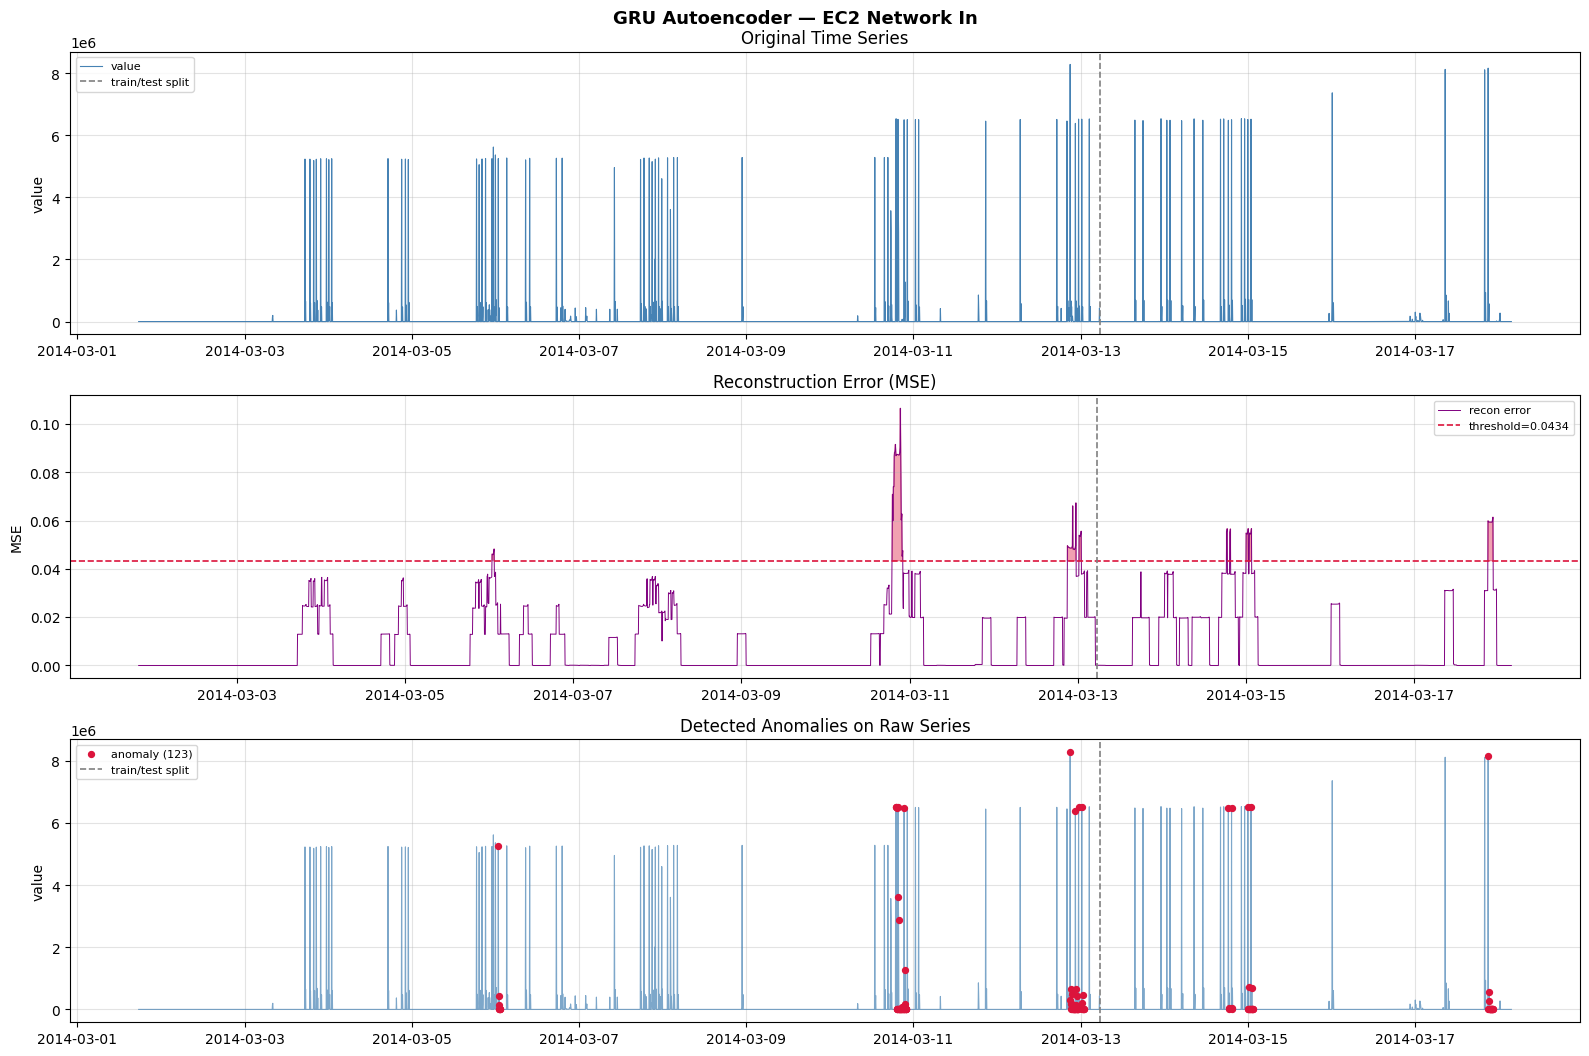

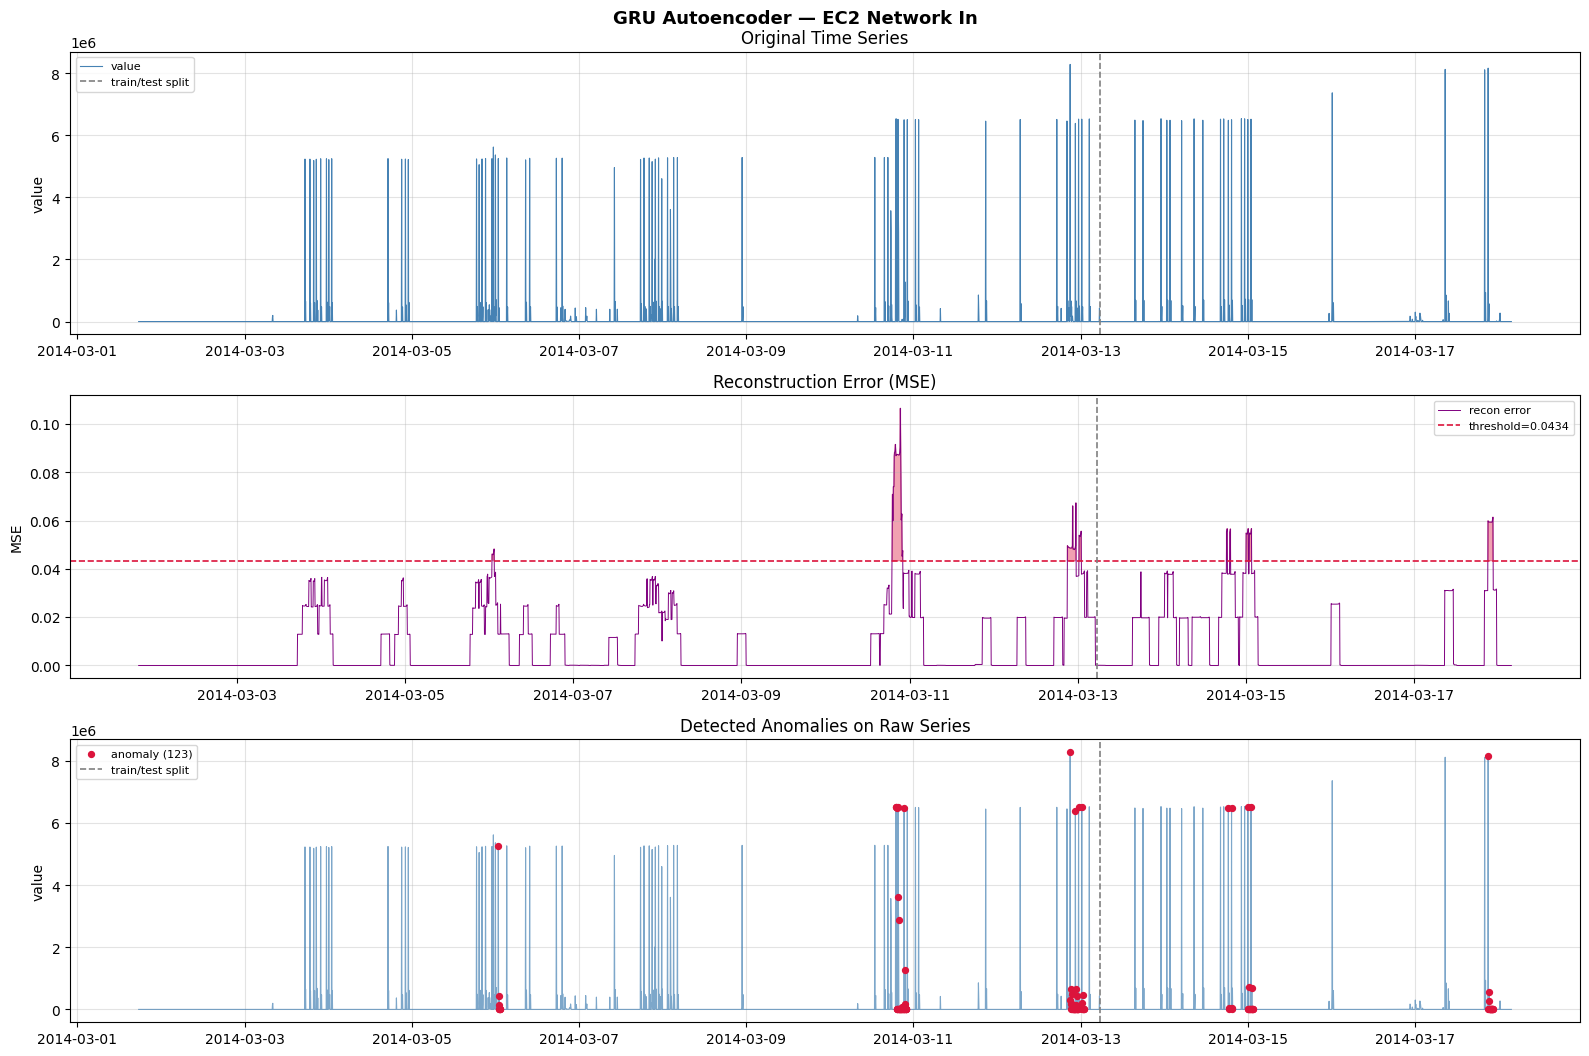

In [33]:
# ── Score & Detect ─────────────────────────────────────────────────────────
net_errors = reconstruction_errors(net_model, X_all_net)
net_labels, net_thresh, _ = get_anomaly_labels(net_errors, len(X_train_net), SIGMA)

print(f"Threshold : {net_thresh:.6f}")
print(f"Anomalies : {net_labels.sum()}  ({100*net_labels.mean():.1f} % of series)")

# ── Plot ───────────────────────────────────────────────────────────────────
plot_gru_results(df, "EC2 Network In",
                 net_errors, net_labels, net_thresh,
                 n_train_net, SEQ_LEN, color="steelblue")


---
## 8. GRU Autoencoder — EC2 CPU Utilisation


Train sequences: 2793  |  All sequences: 4003
Parameters: 91,969

  Epoch   1/60  |  loss = 0.015081
  Epoch  10/60  |  loss = 0.008993
  Epoch  20/60  |  loss = 0.008956
  Epoch  30/60  |  loss = 0.008948
  Epoch  40/60  |  loss = 0.008940
  Early stop at epoch 41


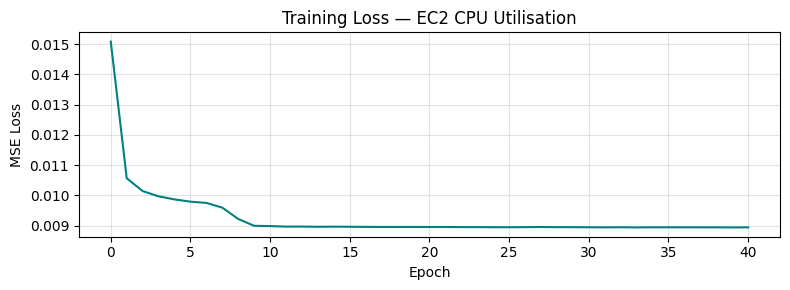

In [34]:
X_train_cpu, X_all_cpu, scaler_cpu, n_train_cpu = prepare_data(
    cpu["value"].values, SEQ_LEN
)
print(f"Train sequences: {len(X_train_cpu)}  |  All sequences: {len(X_all_cpu)}")

cpu_model = GRUAutoencoder(seq_len=SEQ_LEN, n_features=1,
                           hidden_dim=64, n_layers=2, dropout=0.2)
print(f"Parameters: {sum(p.numel() for p in cpu_model.parameters()):,}\n")

cpu_history = train_gru(cpu_model, X_train_cpu, epochs=EPOCHS,
                        batch_size=BATCH, lr=LR)
plot_training_loss(cpu_history, "EC2 CPU Utilisation")


Threshold : 0.021455
Anomalies : 174  (4.3 % of series)


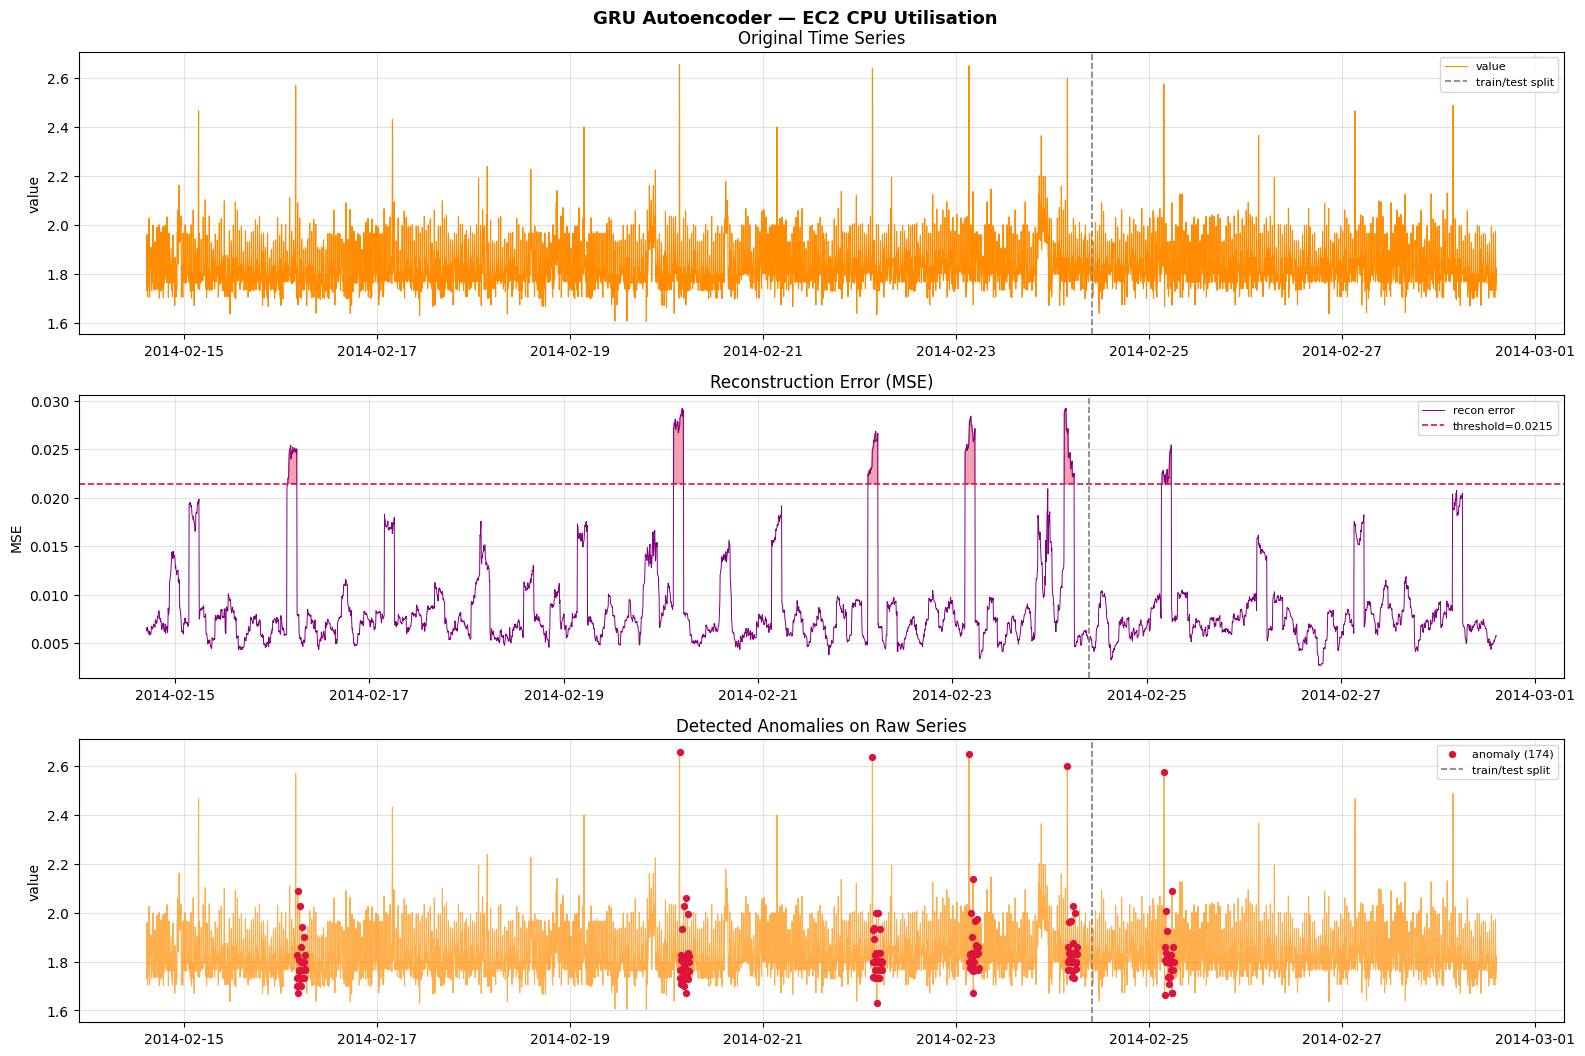

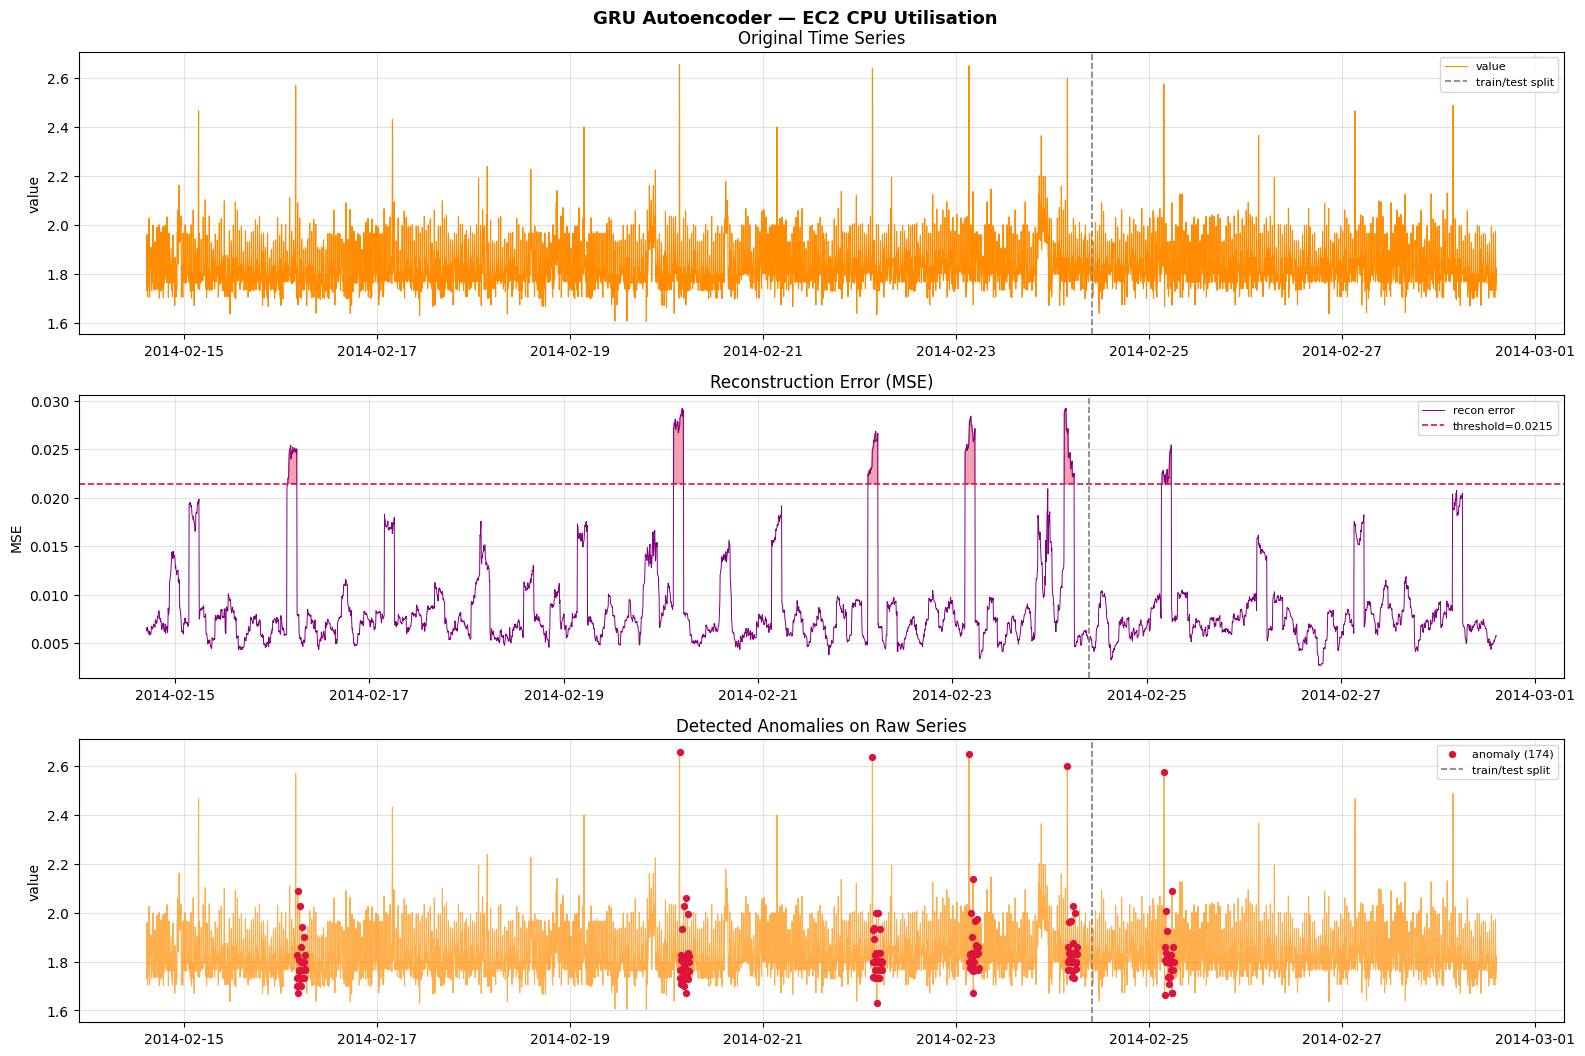

In [35]:
cpu_errors = reconstruction_errors(cpu_model, X_all_cpu)
cpu_labels, cpu_thresh, _ = get_anomaly_labels(cpu_errors, len(X_train_cpu), SIGMA)

print(f"Threshold : {cpu_thresh:.6f}")
print(f"Anomalies : {cpu_labels.sum()}  ({100*cpu_labels.mean():.1f} % of series)")

plot_gru_results(cpu, "EC2 CPU Utilisation",
                 cpu_errors, cpu_labels, cpu_thresh,
                 n_train_cpu, SEQ_LEN, color="darkorange")


---
## 9. GRU Autoencoder — ELB Request Count


Train sequences: 2793  |  All sequences: 4003
Parameters: 91,969

  Epoch   1/60  |  loss = 0.009965
  Epoch  10/60  |  loss = 0.006487
  Epoch  20/60  |  loss = 0.006470
  Epoch  30/60  |  loss = 0.006461
  Early stop at epoch 34


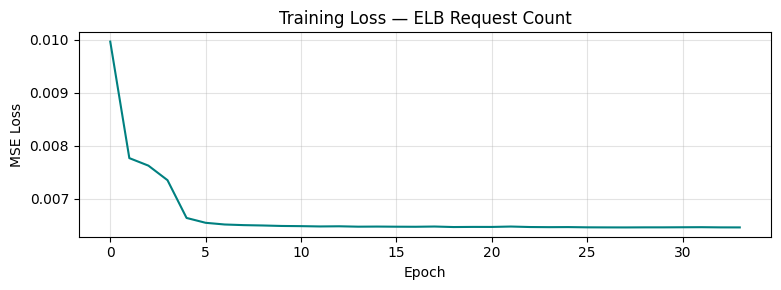

In [36]:
X_train_req, X_all_req, scaler_req, n_train_req = prepare_data(
    request_c["value"].values, SEQ_LEN
)
print(f"Train sequences: {len(X_train_req)}  |  All sequences: {len(X_all_req)}")

req_model = GRUAutoencoder(seq_len=SEQ_LEN, n_features=1,
                           hidden_dim=64, n_layers=2, dropout=0.2)
print(f"Parameters: {sum(p.numel() for p in req_model.parameters()):,}\n")

req_history = train_gru(req_model, X_train_req, epochs=EPOCHS,
                        batch_size=BATCH, lr=LR)
plot_training_loss(req_history, "ELB Request Count")


Threshold : 0.015356
Anomalies : 103  (2.6 % of series)


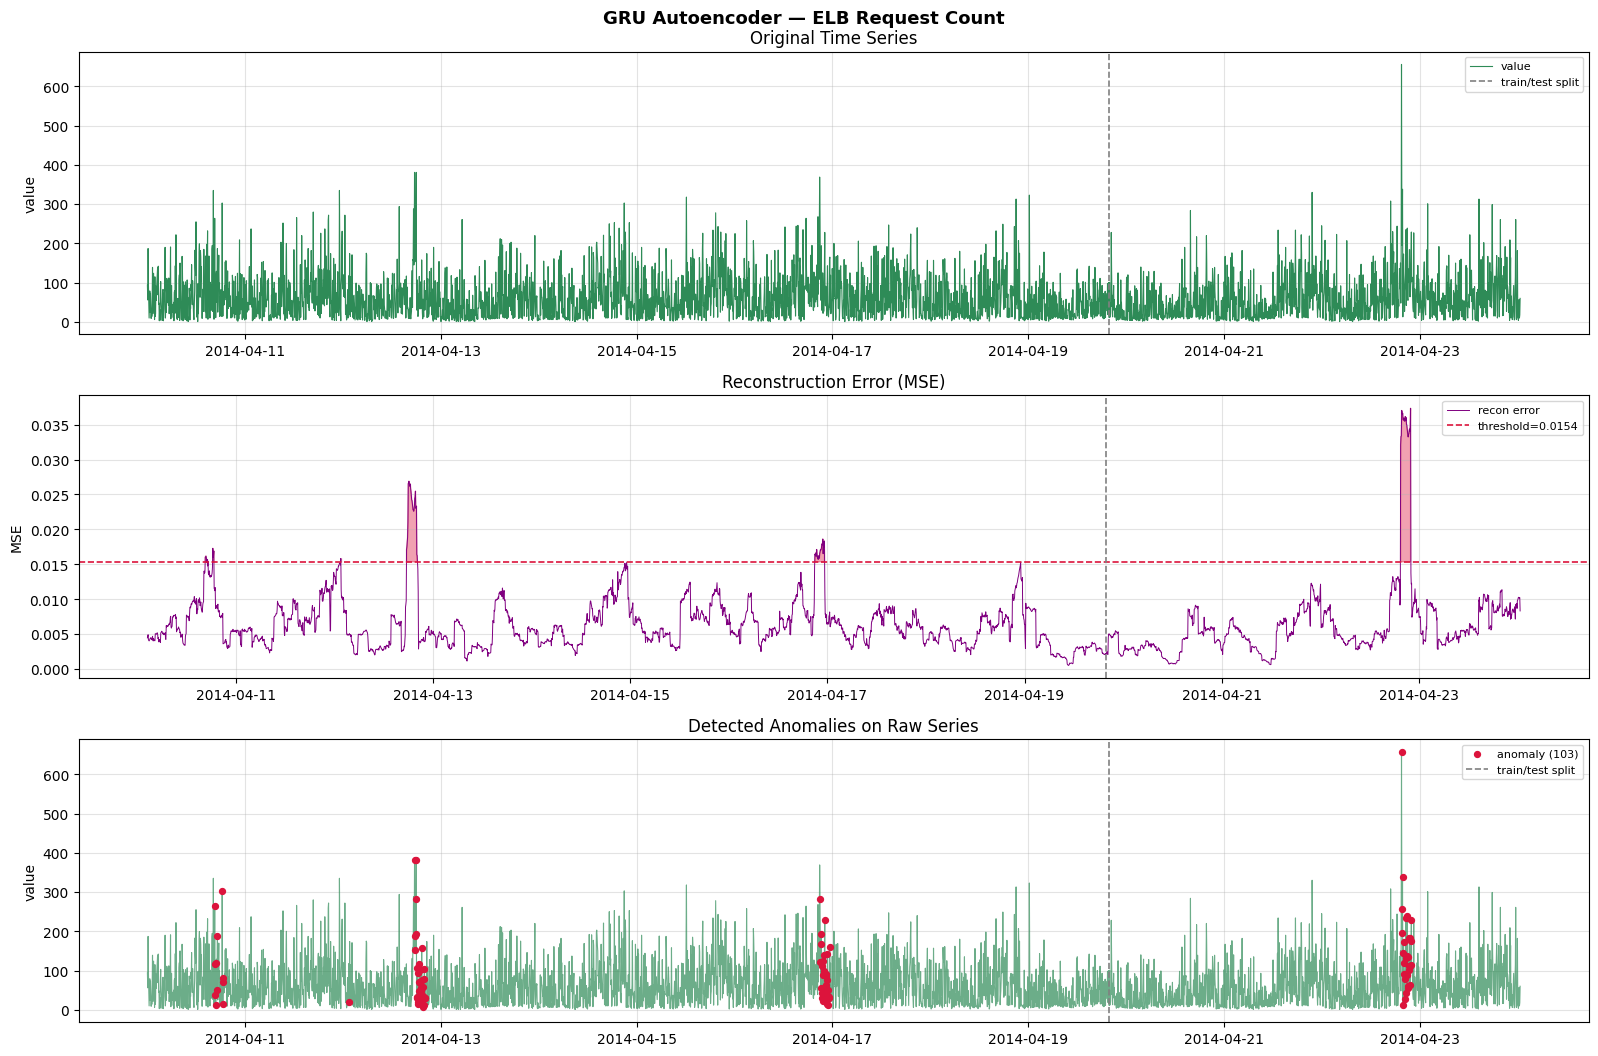

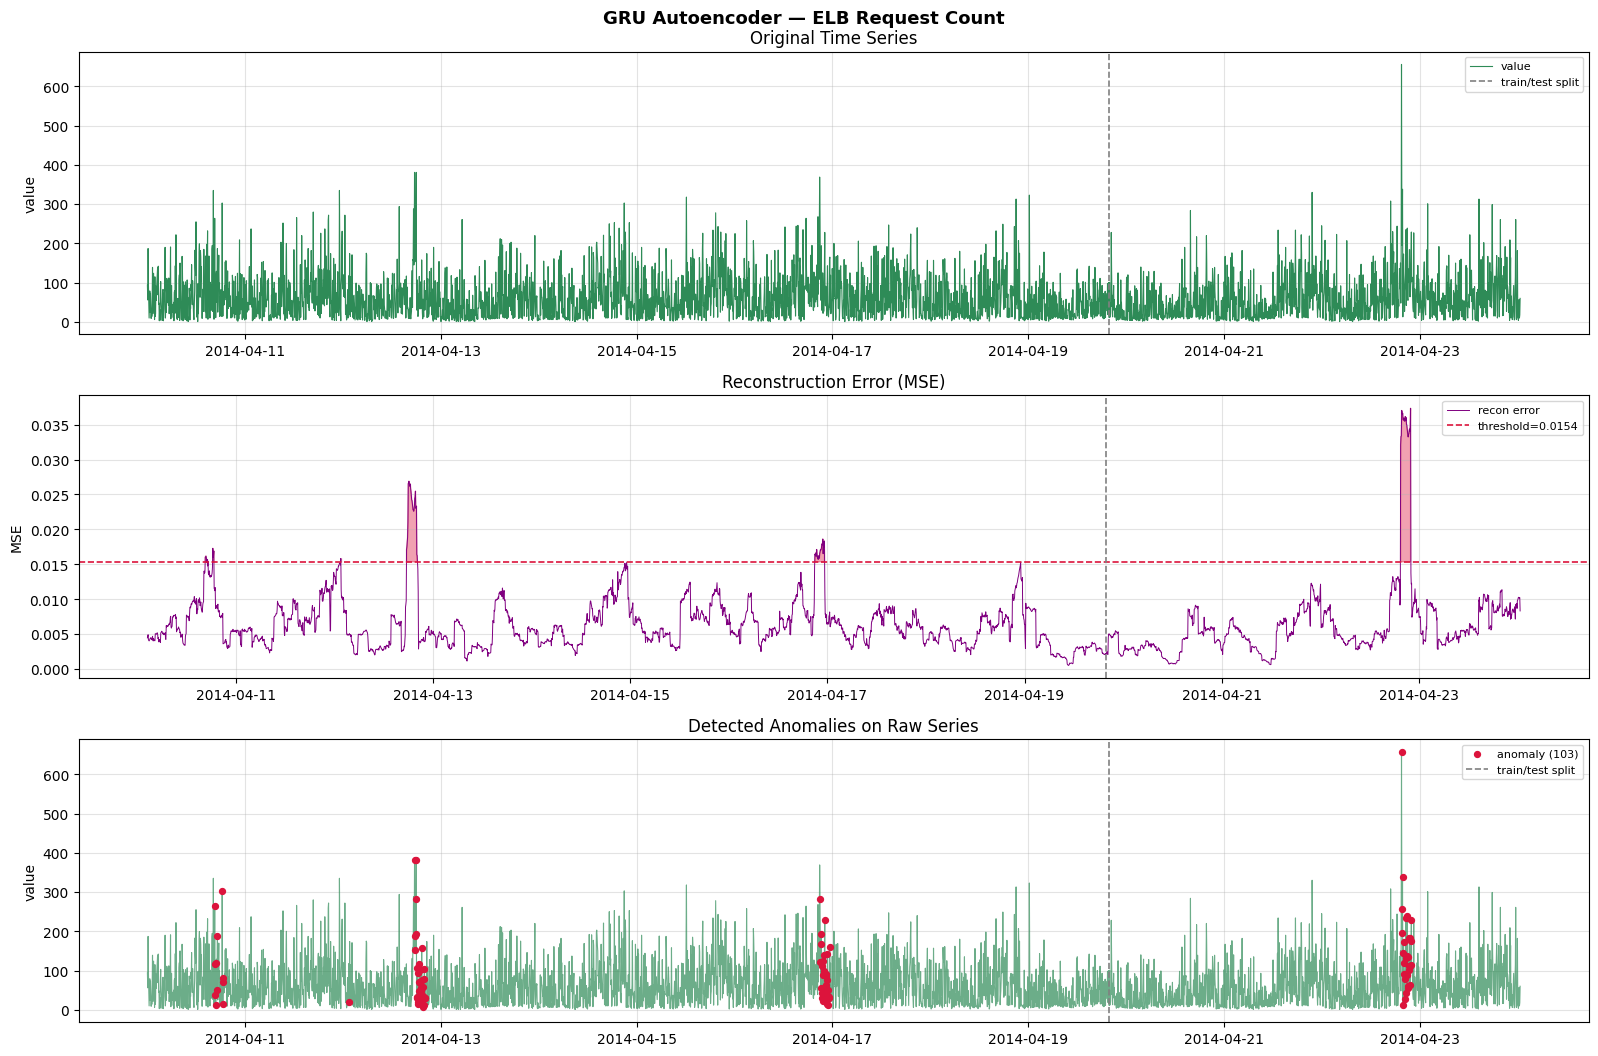

In [37]:
req_errors = reconstruction_errors(req_model, X_all_req)
req_labels, req_thresh, _ = get_anomaly_labels(req_errors, len(X_train_req), SIGMA)

print(f"Threshold : {req_thresh:.6f}")
print(f"Anomalies : {req_labels.sum()}  ({100*req_labels.mean():.1f} % of series)")

plot_gru_results(request_c, "ELB Request Count",
                 req_errors, req_labels, req_thresh,
                 n_train_req, SEQ_LEN, color="seagreen")


---
## 10. Cross-Metric Comparison
Compare GRU anomaly scores across all three series on a shared time axis.


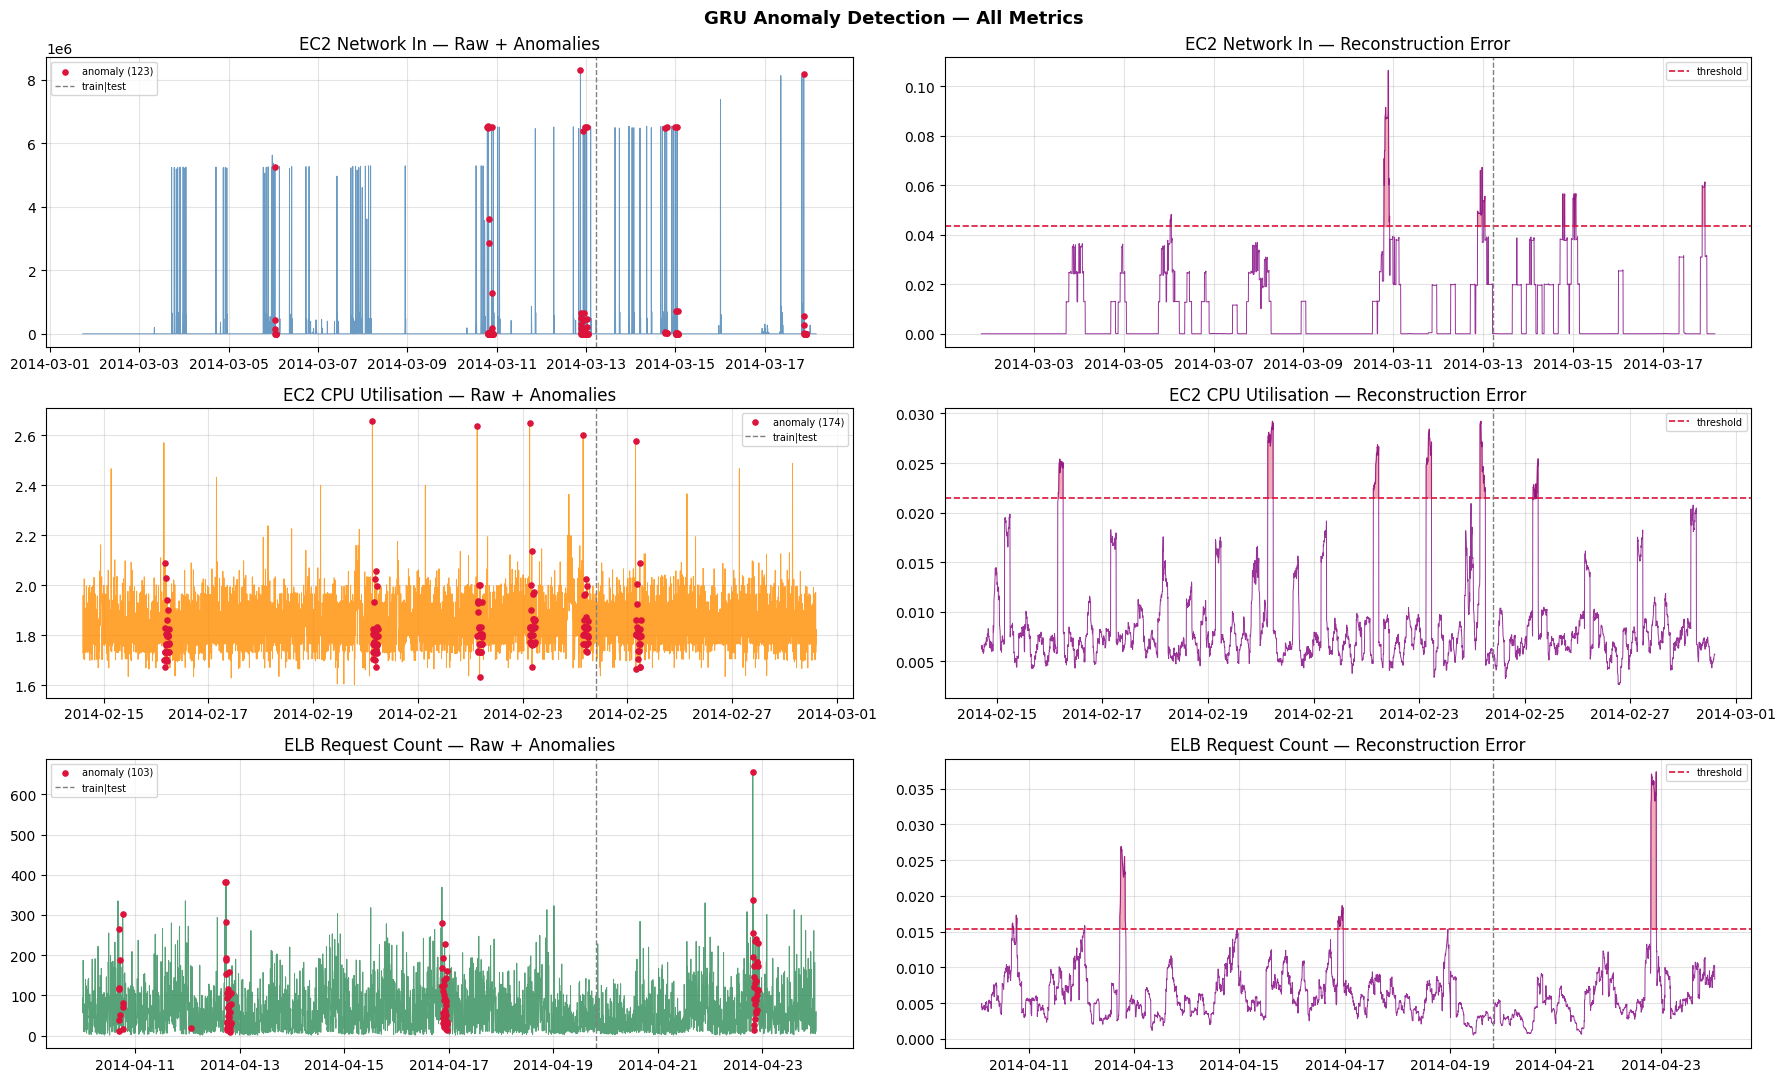

Saved → gru_cross_metric_comparison.png


In [38]:
offset = SEQ_LEN - 1

fig, axes = plt.subplots(3, 2, figsize=(18, 11))
fig.suptitle("GRU Anomaly Detection — All Metrics", fontsize=13, fontweight="bold")

configs = [
    (df,        net_errors, net_labels, net_thresh, n_train_net, "EC2 Network In",      "steelblue"),
    (cpu,       cpu_errors, cpu_labels, cpu_thresh, n_train_cpu, "EC2 CPU Utilisation", "darkorange"),
    (request_c, req_errors, req_labels, req_thresh, n_train_req, "ELB Request Count",   "seagreen"),
]

for row, (frame, errors, labels, thresh, n_train, title, color) in enumerate(configs):
    ts   = frame["timestamp"].values
    vals = frame["value"].values
    err_ts = ts[offset:]

    # Left: raw + anomalies
    ax = axes[row, 0]
    ax.plot(ts, vals, lw=0.7, color=color, alpha=0.8)
    anom = labels == 1
    ax.scatter(err_ts[anom], vals[offset:][anom],
               c="crimson", s=14, zorder=5, label=f"anomaly ({anom.sum()})")
    ax.axvline(ts[n_train], color="gray", ls="--", lw=1, label="train|test")
    ax.set_title(f"{title} — Raw + Anomalies"); ax.legend(fontsize=7)

    # Right: reconstruction error
    ax = axes[row, 1]
    ax.plot(err_ts, errors, lw=0.7, color="purple", alpha=0.8)
    ax.axhline(thresh, color="crimson", ls="--", lw=1.2, label=f"threshold")
    ax.fill_between(err_ts, errors, thresh,
                    where=(errors > thresh), color="crimson", alpha=0.35)
    ax.axvline(ts[n_train], color="gray", ls="--", lw=1)
    ax.set_title(f"{title} — Reconstruction Error"); ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("gru_cross_metric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → gru_cross_metric_comparison.png")


## 12. Save Models & Results

In [40]:
import os
os.makedirs("gru_outputs", exist_ok=True)

# Save model weights
torch.save(net_model.state_dict(), "gru_outputs/gru_network_in.pth")
torch.save(cpu_model.state_dict(), "gru_outputs/gru_cpu.pth")
torch.save(req_model.state_dict(), "gru_outputs/gru_elb_requests.pth")
print("Models saved to gru_outputs/")

# Save per-series anomaly CSVs
def save_results(frame, errors, labels, seq_len, name):
    offset = seq_len - 1
    out = frame[["timestamp","value"]].copy()
    err_col   = pd.Series(np.nan, index=out.index)
    label_col = pd.Series(np.nan, index=out.index)
    err_col.iloc[offset:]   = errors
    label_col.iloc[offset:] = labels
    out["recon_error"]    = err_col
    out["anomaly_gru"]    = label_col
    path = f"gru_outputs/results_{name}.csv"
    out.to_csv(path, index=False)
    print(f"  Saved {path}")

save_results(df,        net_errors, net_labels, SEQ_LEN, "network_in")
save_results(cpu,       cpu_errors, cpu_labels, SEQ_LEN, "cpu")
save_results(request_c, req_errors, req_labels, SEQ_LEN, "elb_requests")

print("\nAll outputs written to → ./gru_outputs/")


Models saved to gru_outputs/
  Saved gru_outputs/results_network_in.csv
  Saved gru_outputs/results_cpu.csv
  Saved gru_outputs/results_elb_requests.csv

All outputs written to → ./gru_outputs/
